In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# numpy  : fast array math and random number generation
# scipy  : gives us the Beta distribution and normal CDF
# matplotlib : plotting the resulting NPV distribution

In [4]:
def pert_sample(low, mode, high, n, lam=4):
    """
    Draw n random samples from a PERT distribution.

    low  : the minimum plausible value  (pessimistic)
    mode : the most likely value        (your best guess)
    high : the maximum plausible value  (optimistic)
    n    : number of random draws
    lam  : weight on the mode (default 4 is standard PERT)

    Internally this is just a Beta distribution rescaled
    to the [low, high] interval. We never need to see the
    Beta parameters directly — that's all handled below.
    """
    mean = (low + lam * mode + high) / (lam + 2)
    # This is the PERT mean formula: endpoints + weighted mode

    if mean == mode:
        alpha = 1 + lam / 2
    else:
        alpha = ((mean - low) * (2 * mode - low - high)) / \
                ((mode - mean) * (high - low))
    # alpha and beta are the two shape parameters of the
    # underlying Beta distribution. You don't need to
    # interpret them — just know larger alpha pulls the
    # distribution left, larger beta pulls it right.

    beta = alpha * (high - mean) / (mean - low)

    # Draw from Beta(alpha, beta), then rescale to [low, high]
    samples = stats.beta.rvs(alpha, beta, size=n)
    return low + samples * (high - low)

In [5]:
def correlated_uniforms(rho, n):
    """
    Generate two streams of uniform [0,1] random numbers
    that are correlated with each other at level rho.

    Why do we need this?
    If we sample amount and duration independently, we
    assume a judge's decisions on each are unrelated.
    In reality they likely move together (negatively —
    high amount, fewer years). The copula imposes that
    relationship without changing each variable's own
    distribution shape.

    How it works:
    1. Draw two correlated standard normal variables
    2. Convert each to uniform [0,1] via the normal CDF
    3. These uniforms carry the correlation through into
       whatever distribution we plug them into next.
    """
    cov_matrix = [[1, rho], [rho, 1]]
    # A 2x2 covariance matrix. Diagonal = variance of 1.
    # Off-diagonal = rho, the correlation we specified.

    normals = np.random.multivariate_normal(
        mean=[0, 0],
        cov=cov_matrix,
        size=n
    )
    # normals is shape (n, 2): n rows, 2 columns
    # column 0 = normal draws for amount
    # column 1 = normal draws for duration

    u1 = stats.norm.cdf(normals[:, 0])
    u2 = stats.norm.cdf(normals[:, 1])
    # .cdf() converts each normal value to its percentile,
    # which is always between 0 and 1 — now uniform [0,1]

    return u1, u2

In [6]:
def npv_maintenance(annual_amount, n_years, discount_rate):
    """
    Present value of receiving annual_amount per year
    for n_years, discounted at discount_rate.

    We treat each year as a separate cash flow and
    discount it back to today — same logic as npv_uneven
    from earlier, just applied to maintenance payments.

    Note: n_years comes in as a float from the PERT
    sampler, so we round it to the nearest integer first.
    """
    n_years = int(round(n_years))
    pv = 0
    for t in range(1, n_years + 1):
        pv += annual_amount / (1 + discount_rate) ** t
    return pv

In [19]:
# --- Spousal maintenance amount (annual, $) ---
amount_low  = 36_000   # worst case for payor: judge awards this minimum
amount_mode = 72_000   # your attorney's best guess
amount_high = 120_000   # worst case: judge awards this maximum

# --- Duration (years) ---
years_low  = 5         # shortest plausible award
years_mode = 10         # most likely duration
years_high = 17        # longest plausible award

# --- Correlation between amount and duration ---
rho = 0.45             # negative: higher amount → fewer years (adjust as needed)

# --- Discount rate ---
discount_rate = 0.04   # reflect cost of capital or investment return available

# --- Simulation size ---
n_sims = 1_000_000        # 50,000 simulated trial outcomes

In [20]:
# Step 6a: generate correlated uniform [0,1] pairs
u_amount, u_years = correlated_uniforms(rho, n_sims)

# Step 6b: plug those uniforms into the PERT quantile function
# ppf() = "percent point function" = inverse CDF
# It takes a probability (0-1) and returns the PERT value at that percentile
# This is how we combine the copula with our PERT distributions
mean_a = (amount_low + 4 * amount_mode + amount_high) / 6
alpha_a = ((mean_a - amount_low) * (2 * amount_mode - amount_low - amount_high)) / \
          ((amount_mode - mean_a) * (amount_high - amount_low))
beta_a  = alpha_a * (amount_high - mean_a) / (mean_a - amount_low)
amounts = amount_low + stats.beta.ppf(u_amount, alpha_a, beta_a) * (amount_high - amount_low)

mean_y = (years_low + 4 * years_mode + years_high) / 6
alpha_y = ((mean_y - years_low) * (2 * years_mode - years_low - years_high)) / \
          ((years_mode - mean_y) * (years_high - years_low))
beta_y  = alpha_y * (years_high - mean_y) / (mean_y - years_low)
years   = years_low + stats.beta.ppf(u_years, alpha_y, beta_y) * (years_high - years_low)

# Step 6c: compute NPV for each of the 50,000 simulated outcomes
npvs = np.array([
    npv_maintenance(a, y, discount_rate)
    for a, y in zip(amounts, years)
])

Mean NPV:         $     622,328
Median NPV:       $     601,762
10th percentile:  $     366,832
90th percentile:  $     909,384
Std deviation:    $     206,553


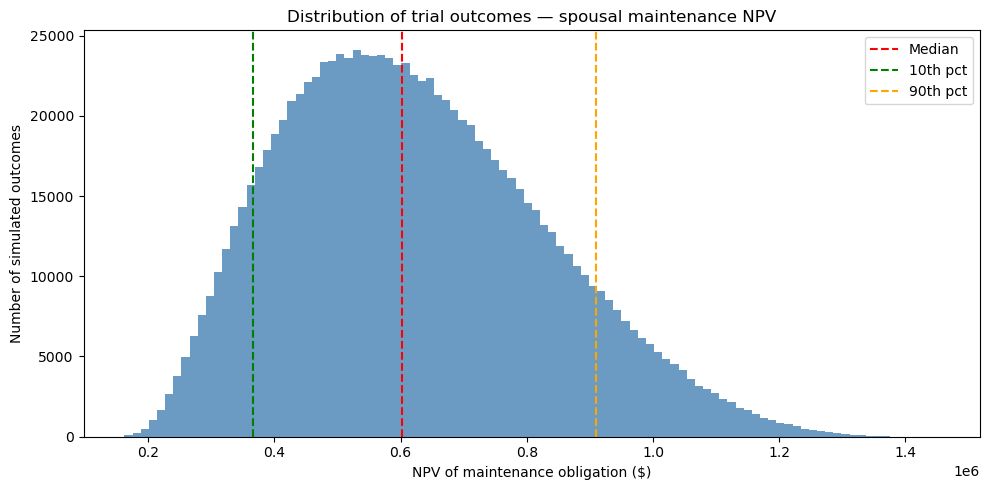

In [21]:
print(f"Mean NPV:         ${np.mean(npvs):>12,.0f}")
print(f"Median NPV:       ${np.median(npvs):>12,.0f}")
print(f"10th percentile:  ${np.percentile(npvs, 10):>12,.0f}")  # good outcome for payor
print(f"90th percentile:  ${np.percentile(npvs, 90):>12,.0f}")  # bad outcome for payor
print(f"Std deviation:    ${np.std(npvs):>12,.0f}")            # width of uncertainty

# Plot the full distribution
plt.figure(figsize=(10, 5))
plt.hist(npvs, bins=100, edgecolor='none', color='steelblue', alpha=0.8)
plt.axvline(np.median(npvs), color='red', linestyle='--', label='Median')
plt.axvline(np.percentile(npvs, 10), color='green', linestyle='--', label='10th pct')
plt.axvline(np.percentile(npvs, 90), color='orange', linestyle='--', label='90th pct')
plt.xlabel("NPV of maintenance obligation ($)")
plt.ylabel("Number of simulated outcomes")
plt.title("Distribution of trial outcomes — spousal maintenance NPV")
plt.legend()
plt.tight_layout()
plt.show()

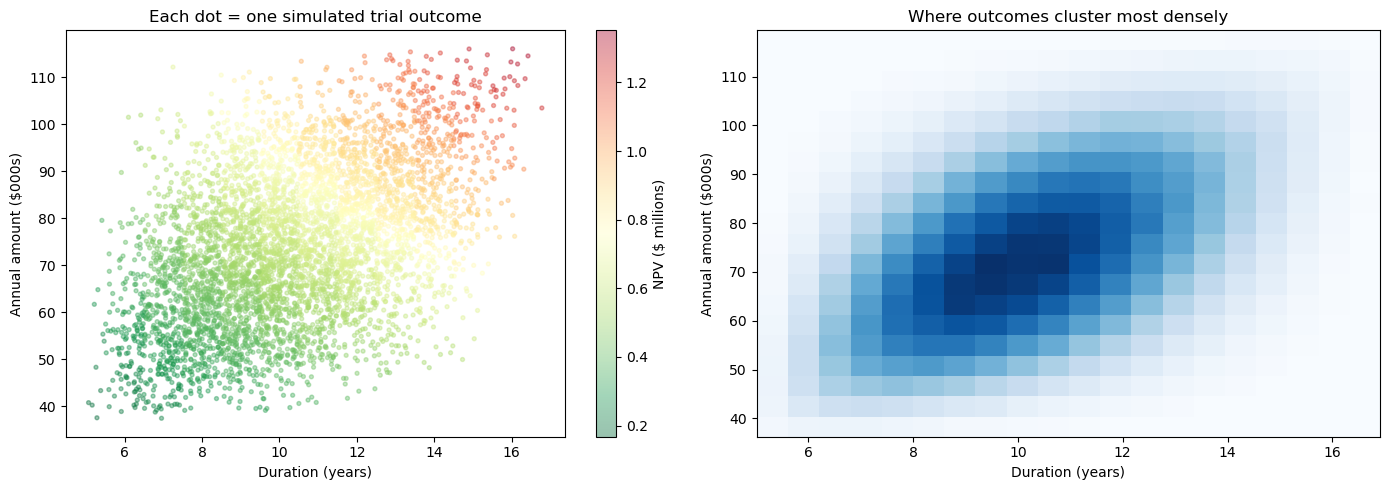

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: scatter plot of amount vs years, colored by NPV ---
# Subsample for plotting speed (5000 points is plenty visually)
idx = np.random.choice(len(amounts), 5000, replace=False)
sc = axes[0].scatter(
    years[idx],
    amounts[idx] / 1000,        # convert to thousands for readability
    c=npvs[idx] / 1_000_000,    # color = NPV in millions
    cmap='RdYlGn_r',            # red = high NPV (bad for payor), green = low
    alpha=0.4,
    s=8
)
plt.colorbar(sc, ax=axes[0], label='NPV ($ millions)')
axes[0].set_xlabel('Duration (years)')
axes[0].set_ylabel('Annual amount ($000s)')
axes[0].set_title('Each dot = one simulated trial outcome')

# --- Right: heat map of outcome frequency by amount and duration buckets ---
h, xedges, yedges = np.histogram2d(
    years,
    amounts / 1000,
    bins=20
)
axes[1].imshow(
    h.T,
    origin='lower',
    aspect='auto',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='Blues'
)
axes[1].set_xlabel('Duration (years)')
axes[1].set_ylabel('Annual amount ($000s)')
axes[1].set_title('Where outcomes cluster most densely')

plt.tight_layout()
plt.show()

In [24]:
def npv_even_loop(rate, cash_flow, n_periods, initial_investment):
    pv_total = 0
    for t in range(1, n_periods + 1):
        pv_total += cash_flow / (1 + rate) ** t
    return pv_total - initial_investment

In [31]:
retirement = 1_000_000
rate       = 0.04

j_monthly  = 10_000        # positive — function treats cash_flow as an outflow implicitly
j_annual   = j_monthly * 12
j_years    = 16
j_split    = 0.53          # positive — function subtracts this as initial_investment

k_monthly  = 5_833
k_annual   = k_monthly * 12
k_years    = 8
k_split    = 0.53

scen_1_jen   = npv_even_loop(rate, j_annual, j_years, 0)
scen_1_kelly = npv_even_loop(rate, k_annual, k_years, 0)

print(f"The NPV of Jen's proposal is   ${scen_1_jen:,.2f}.")
print(f"The NPV of Kelly's proposal is ${scen_1_kelly:,.2f}.")
print(f"The difference is              ${scen_1_jen - scen_1_kelly:,.2f}.")
print(f"With her proposed split of retirement and maintenance she would receive ${(retirement * j_split) + scen_1_jen:,.2f}.")
print(f"With my proposed split of retirement and maintenance she would receive ${(retirement * k_split) + scen_1_kelly:,.2f}.")

The NPV of Jen's proposal is   $1,398,275.47.
The NPV of Kelly's proposal is $471,265.21.
The difference is              $927,010.26.
With her proposed split of retirement and maintenance she would receive $1,928,275.47.
With my proposed split of retirement and maintenance she would receive $1,001,265.21.
